# Predicted comments 

This notebook implements a series of different ML model out of the box, to try and predict the number of comments left on planning applications based on a set of variables. 

First I combine my datasets to get all my variables in one dataframe. The datasets are: 
- Comments dataset - used to group the number of comments on each application 
- application_df - this is the lsit of application id's used for webscraping - I use this to ensure consistent matching 
- pld_df - this is the dataset direct from the planning london datahub (via ElasticSearch)

After some pre-processing I then use ML models to look at the relationship between different variables and the number of comments left. 

The models used are: 
- Regression 
- Random forest 
- XGBoost 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import xgboost as xgb

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

from database.comments import Comments

import seaborn as sns

import sys
sys.path.append('../functions')
import preprocessing_fncs as ppf
from elastic_search_fncs import ElasticSearchFncs

## Load the datasets

Comments dataset - webscraped free-text comments. 

In [2]:
# Comments dataset
cs = Comments(env="dev")
comment_df = cs.read_all().copy()
comment_df = ppf.format_borough(comment_df, 'council')

comment_df.head()

Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score
0,86049,Barnet,21/2810/FUL_2,21/2810/FUL,"6 Tangmere Way London, United Kingdom NW9 5WW",Objects,2021-06-22,some residents in Gaydon lane have raised conc...,2025-04-10,51.599700,-0.248590,some residents in have raised concerns about t...,E09000003,-0.084598
1,78219,Barnet,24/3762/FUL_36,24/3762/FUL,88 Westbury Road London N12 7PD,Objects,2024-10-02,I am writing to express my strong objection to...,2025-04-08,51.612910,-0.189180,I am writing to express my strong objection to...,E09000003,-0.362558
2,86056,Barnet,21/2810/FUL_9,21/2810/FUL,1 Gaydon Lane Colindale London NW9 5WA,Objects,2021-06-20,"1. From the plans and elevations, the proposed...",2025-04-10,51.601675,-0.252985,"1. From the plans and elevations, the proposed...",E09000003,-0.424556
3,86065,Barnet,21/2810/FUL_18,21/2810/FUL,7 Elvington Lane London nw9 5wb,Objects,2021-06-08,we dont want this houses at the bottom of our ...,2025-04-10,51.602100,-0.252440,we dont want this houses at the bottom of our ...,E09000003,-0.365758
4,86321,Brent,22/1280_1,22/1280,"69 Crundale Avenue, London, NW9 9PJ",Neutral,2022-05-11,I am not objecting to this planning applicatio...,2025-04-10,51.584920,-0.276780,I am not objecting to this planning applicatio...,E09000005,0.019409


Applications dataset - list of applciation IDs used for webscraping. 

In [3]:
# Application dataset 
application_df_path = "/Users/bea/Documents/AI4CI/projects/comment_summariser/comment_summariser/data/PLD_application_ids/all_since21_cleaned.csv"
application_df = pd.read_csv(application_df_path)
print(f"There are {len(application_df)} applications in the dataset.")

# drop 'Bromley' applications -  since I haven't been able to get the comments for these
application_df = application_df[application_df['borough'] != 'Bromley']
print(f"There are {len(application_df)} applications in the dataset after dropping Bromley applications.")

application_df = ppf.format_df(application_df, 'borough')

There are 5850 applications in the dataset.
There are 5077 applications in the dataset after dropping Bromley applications.


In [4]:
# format the application_df by adding comment counts
app_count = comment_df.groupby('application_id')['id'].count().reset_index()
app_count.columns = ['application_id', 'comment_count']

application_df = application_df.merge(app_count, left_on='lpa_app_no', right_on='application_id', how='left')
application_df['comment_count'] = application_df['comment_count'].fillna(0).astype(int)
application_df.drop(columns=['application_id'], inplace=True)

In [5]:
# Run the formatting functions 
application_df = ppf.format_df(application_df)

# TODO: check logic of this function - I think soem columns are empty 
# application_df = ppf.create_decision_outcomes(application_df, completion_date_col_name='decision_date')

In [6]:
# Check for non-unique 'lpa_app_no' values
# Some boroughs use the same application number format, so there may be duplicates across boroughs

# return application_df where 'lpa_app_no' is not unique
application_df[application_df.duplicated(subset=['lpa_app_no'], keep=False)].sort_values(by=['lpa_app_no'])

,lpa_app_no,valid_date,decision_date,borough,total_no_proposed_residential_units,total_no_affordable_units,site_area,habitable_rooms_density,pp_id,uprn,status,decision,street_name,site_name,site_number,polygon,wgs84_polygon,description,comment_count
1626,21/03029/FUL,NaT,NaT,Lambeth,8,NaN,663.00000,0.036199,PP-10065540,1.000219e+11,Approved,Approved,Kingsmead Road,NaN,89,GEOMETRYCOLLECTION (POLYGON ((531174.583375 17...,"polygon=linearring(x=[-0.11412889999999999, -0...",Demolition of existing house and erection of a...,41
2069,21/03029/FUL,NaT,NaT,Newham,1,NaN,NaN,NaN,PP-10446127,1.009488e+10,Refused,Refused,Romford Road,Development Site Rear Of 865,NaN,GEOMETRYCOLLECTION (POLYGON ((542572.0 185871....,"polygon=linearring(x=[0.055038, 0.055067, 0.05...",Demolition of existing storage structure and t...,41
872,22/02530/FUL,NaT,NaT,Newham,1,NaN,100.00000,0.010000,PP-11642396,4.600363e+07,Commenced,Approved,NaN,144 Barking Road,NaN,NaN,NaN,NaN,8
1785,22/02530/FUL,NaT,NaT,Lambeth,1,NaN,155.00000,0.012903,PP-11388806,1.000233e+11,Commenced,Approved,Streatham Vale,NaN,29,GEOMETRYCOLLECTION (POLYGON ((529676.209375 17...,"polygon=linearring(x=[-0.1365372, -0.1366097, ...",Retrospective change of use of the rear of the...,8
4453,22/02599/FUL,NaT,NaT,Lambeth,9,NaN,NaN,NaN,PP-11386341,1.000233e+11,Dismissed,Refused,Streatham High Road,NaN,"620, 626",GEOMETRYCOLLECTION (POLYGON ((530526.492875 17...,"polygon=linearring(x=[-0.1243947, -0.1246742, ...",Erection of three storey extension to create 9...,1
4781,22/02599/FUL,NaT,NaT,Newham,2,NaN,92.00000,0.021739,PP-11664621,1.000899e+10,Commenced,Approved,NaN,7 Prince Regent Lane,NaN,NaN,NaN,NaN,1
1560,23/00702/FUL,NaT,NaT,Lambeth,1,NaN,80.54000,0.037249,PP-11918401,2.000005e+11,Approved,Approved,Norwood High Street,NaN,121,GEOMETRYCOLLECTION (POLYGON ((532122.023375 17...,"polygon=linearring(x=[-0.10085329999999999, -0...","Refurbishment of the property, involving erect...",0
2949,23/00702/FUL,NaT,NaT,Newham,2,NaN,NaN,NaN,PP-11874782,1.000899e+10,Dismissed,Refused,High Street North,NaN,105,NaN,"polygon=linearring(x=[0.052142, 0.05214, 0.052...",Proposed two-storey extension to the rear of e...,0
411,23/01143/FUL,NaT,NaT,Newham,5,NaN,NaN,NaN,PP-12189160,1.000899e+10,Refused,Refused,Plashet Grove,NaN,167,NaN,"polygon=linearring(x=[0.042087, 0.042086, 0.04...","Redevelopment to form part-three, part- four s...",3
1439,23/01143/FUL,NaT,NaT,Lambeth,1,NaN,NaN,NaN,PP-11957518,1.000218e+11,Approved,Approved,NaN,66 Hatfields,NaN,NaN,NaN,NaN,3


Planning London Datahub - this the dataset with detailed tabular and geospatial info 

In [7]:
esf = ElasticSearchFncs()
esf.check_connection()

Connected to Elastic Search


In [8]:
pld_df = esf.res_units_x_query(min_res_units=1, since_year="01/01/2021", to_year="01/05/2025")

In [9]:
# Run the formatting functions on pld_df
pld_df = ppf.format_df(pld_df)
# Add column for hosuing type - based on logic regarding number of residential units
pld_df = ppf.add_housing_type(pld_df)

## Dataset processing 

### MERGE! datasets 

Merge and match the datasets from the different sources. 

In [10]:
application_df['lpa_app_no_borough'] = application_df['lpa_app_no'] + '_' + application_df['borough']
pld_df['lpa_app_no_borough'] = pld_df['lpa_app_no'] + '_' + pld_df['borough']

# to avoid duplciation afetr merging 
application_df.drop(columns=['decision_date', 'valid_date'], inplace=True)

In [11]:
df = pd.merge(application_df, pld_df[['housing_type', 'decision_date', 'valid_date', 'lpa_app_no_borough', 'actual_completion_date', 'wgs84_polygon.coordinates', 'polygon.coordinates', 'postcode']], left_on='lpa_app_no_borough', right_on='lpa_app_no_borough', how='left')

In [12]:
df.isna().sum()

lpa_app_no                                0
borough                                   0
total_no_proposed_residential_units       0
total_no_affordable_units              5072
site_area                              4490
habitable_rooms_density                4490
pp_id                                     0
uprn                                      1
status                                   52
decision                                 56
street_name                            1687
site_name                              1704
site_number                            3040
polygon                                2485
wgs84_polygon                          2009
description                             660
comment_count                             0
lpa_app_no_borough                        0
housing_type                            122
decision_date                           123
valid_date                              122
actual_completion_date                 4231
wgs84_polygon.coordinates       

In [13]:
df = ppf.create_decision_outcomes(df, completion_date_col_name='decision_date')

In [14]:
df.isna().sum()

lpa_app_no                                0
borough                                   0
total_no_proposed_residential_units       0
total_no_affordable_units              5072
site_area                              4490
habitable_rooms_density                4490
pp_id                                     0
uprn                                      1
status                                   52
decision                                 56
street_name                            1687
site_name                              1704
site_number                            3040
polygon                                2485
wgs84_polygon                          2009
description                             660
comment_count                             0
lpa_app_no_borough                        0
housing_type                            122
decision_date                           123
valid_date                              122
actual_completion_date                 4231
wgs84_polygon.coordinates       

In [15]:
df.columns

Index(['lpa_app_no', 'borough', 'total_no_proposed_residential_units',
       'total_no_affordable_units', 'site_area', 'habitable_rooms_density',
       'pp_id', 'uprn', 'status', 'decision', 'street_name', 'site_name',
       'site_number', 'polygon', 'wgs84_polygon', 'description',
       'comment_count', 'lpa_app_no_borough', 'housing_type', 'decision_date',
       'valid_date', 'actual_completion_date', 'wgs84_polygon.coordinates',
       'polygon.coordinates', 'postcode', 'outcome'],
      dtype='object')

In [16]:
# Check expected number of unique applications
print(df['lpa_app_no'].isin(application_df['lpa_app_no']).sum())
print(df['lpa_app_no_borough'].nunique())

5078
5077


In [17]:
# return the non unique value of df 'lpa_app_no_borough'
df[df.duplicated(subset=['lpa_app_no_borough'], keep=False)].sort_values(by=['lpa_app_no_borough'])

,lpa_app_no,borough,total_no_proposed_residential_units,total_no_affordable_units,site_area,habitable_rooms_density,pp_id,uprn,status,decision,...,comment_count,lpa_app_no_borough,housing_type,decision_date,valid_date,actual_completion_date,wgs84_polygon.coordinates,polygon.coordinates,postcode,outcome
2997,214465OPDFUL,Ealing,462,NaN,0.13,0.0,PP-09874188,12141006.0,Commenced,Approved,...,31,214465OPDFUL_Ealing,Mixed affordable housing,2023-05-03,2021-06-02,NaT,"[[[-0.259098, 51.522703], [-0.258842, 51.52264...",NaN,W3 6UL,Permitted
2998,214465OPDFUL,Ealing,462,NaN,0.13,0.0,PP-09874188,12141006.0,Commenced,Approved,...,31,214465OPDFUL_Ealing,Mixed affordable housing,2023-05-03,2021-06-02,NaT,NaN,NaN,W3 6UL,Permitted


In [18]:
# ok, the duplciates come from it being recorded in two different LPAs - Ealing and OPDC
# drop df duplicates
df = df.drop_duplicates(subset=['lpa_app_no_borough'], keep='first')

## Prep the datasets for modelling 

In [19]:
df_gpd = ppf.format_polygon(df)

/Users/bea/Documents/AI4CI/projects/comment_summariser/neighour_nlp/notebooks/../functions/preprocessing_fncs.py:362: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid'] = gdf['geometry'].centroid


In [20]:
df_gpd.isna().sum()

lpa_app_no                                0
borough                                   0
total_no_proposed_residential_units       0
total_no_affordable_units              5071
site_area                              4490
habitable_rooms_density                4490
pp_id                                     0
uprn                                      1
status                                   52
decision                                 56
street_name                            1687
site_name                              1704
site_number                            3039
polygon                                2485
wgs84_polygon                          2009
description                             660
comment_count                             0
lpa_app_no_borough                        0
housing_type                            122
decision_date                           123
valid_date                              122
actual_completion_date                 4230
wgs84_polygon.coordinates       

In [21]:
# add column with site area in m2
df = pd.merge(df, df_gpd[['lpa_app_no_borough', 'polygon_area_m2']], left_on='lpa_app_no_borough', right_on='lpa_app_no_borough', how='left')

In [22]:
df.head()

,lpa_app_no,borough,total_no_proposed_residential_units,total_no_affordable_units,site_area,habitable_rooms_density,pp_id,uprn,status,decision,...,lpa_app_no_borough,housing_type,decision_date,valid_date,actual_completion_date,wgs84_polygon.coordinates,polygon.coordinates,postcode,outcome,polygon_area_m2
0,24/02204/FUL,Newham,1,NaN,NaN,NaN,PP-12728004,1.002400e+10,Approved,Approved,...,24/02204/FUL_Newham,Market housing,2025-03-25,2024-11-19,NaT,"[[[0.001716, 51.547651], [0.001703, 51.547679]...",NaN,E15 1JQ,Permitted,203.397965
1,25/0089,Brent,1,NaN,NaN,NaN,PP-13670128,2.022052e+08,Approved,Approved,...,25/0089_Brent,Market housing,2025-03-24,2025-01-27,NaT,NaN,"[[[523522.7, 185196.2], [523522.95, 185196.2],...",None,Permitted,463.939276
2,24/1783,Brent,9,NaN,NaN,NaN,PP-12267268,2.021029e+08,Refused,Refused,...,24/1783_Brent,Market housing,2025-03-24,2024-08-05,NaT,NaN,NaN,None,Permitted,NaN
3,25/00205/PRECOU,Newham,2,NaN,NaN,NaN,PP-13735437,1.000900e+10,NaN,Refused,...,25/00205/PRECOU_Newham,Market housing,2025-03-25,2025-02-03,NaT,"[[[0.024619, 51.549902], [0.024663, 51.549928]...",NaN,E7 9BB,Permitted,279.957868
4,25/00181/PRECOU,Newham,1,NaN,NaN,NaN,PP-13687528,1.009348e+10,NaN,Refused,...,25/00181/PRECOU_Newham,Market housing,2025-03-26,2025-01-30,NaT,"[[[0.020766, 51.546614], [0.020563, 51.546582]...",NaN,E7 9AE,Permitted,193.270297


In [23]:
# return how many na values there are in each column
df.isna().sum()

lpa_app_no                                0
borough                                   0
total_no_proposed_residential_units       0
total_no_affordable_units              5071
site_area                              4490
habitable_rooms_density                4490
pp_id                                     0
uprn                                      1
status                                   52
decision                                 56
street_name                            1687
site_name                              1704
site_number                            3039
polygon                                2485
wgs84_polygon                          2009
description                             660
comment_count                             0
lpa_app_no_borough                        0
housing_type                            122
decision_date                           123
valid_date                              122
actual_completion_date                 4230
wgs84_polygon.coordinates       

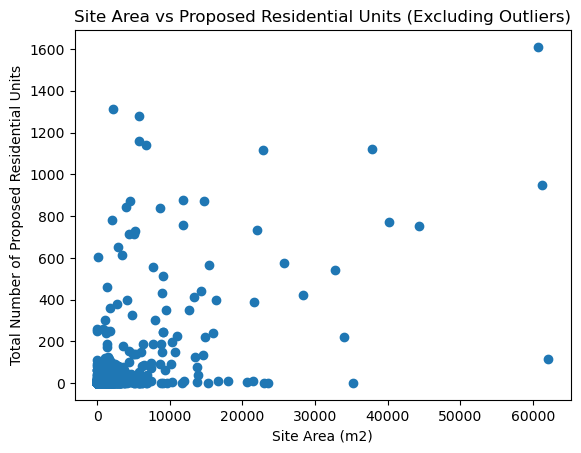

In [24]:
# scatter plot of polygon_area_m2 vs total_no_proposed_residential_units excluding outliers
# plt.scatter(df['polygon_area_m2'], df['total_no_proposed_residential_units'])
plt.scatter(df[df['polygon_area_m2'] < 100000]['polygon_area_m2'], df[df['polygon_area_m2'] < 100000]['total_no_proposed_residential_units'])
plt.xlabel('Site Area (m2)')
plt.ylabel('Total Number of Proposed Residential Units')
plt.title('Site Area vs Proposed Residential Units (Excluding Outliers)')
plt.show()

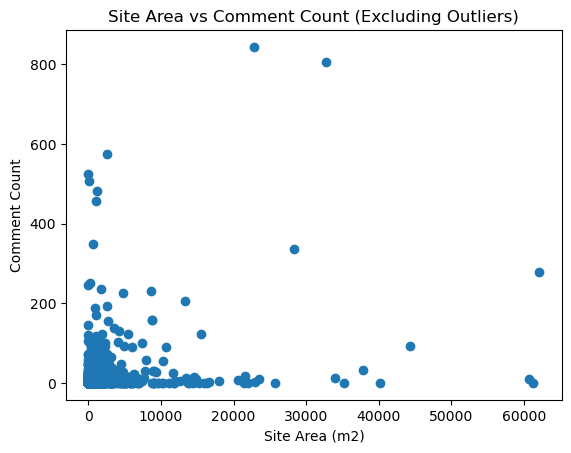

In [25]:
# scatter plot of polygon_area_m2 vs comment_count
plt.scatter(df[df['polygon_area_m2'] < 100000]['polygon_area_m2'], df[df['polygon_area_m2'] < 100000]['comment_count'])
plt.xlabel('Site Area (m2)')
plt.ylabel('Comment Count')
plt.title('Site Area vs Comment Count (Excluding Outliers)')
plt.show()

### Random Forest classifier 

Here implement a random forest classifier to predict if applications will receive comments (True/False), based on a set of variables. 

In [26]:
# add a binary column for comment truth - as this is something I want to try and predict 
df['comment_truth'] = np.where(df['comment_count'] > 0, 1, 0)
df.head()

,lpa_app_no,borough,total_no_proposed_residential_units,total_no_affordable_units,site_area,habitable_rooms_density,pp_id,uprn,status,decision,...,housing_type,decision_date,valid_date,actual_completion_date,wgs84_polygon.coordinates,polygon.coordinates,postcode,outcome,polygon_area_m2,comment_truth
0,24/02204/FUL,Newham,1,NaN,NaN,NaN,PP-12728004,1.002400e+10,Approved,Approved,...,Market housing,2025-03-25,2024-11-19,NaT,"[[[0.001716, 51.547651], [0.001703, 51.547679]...",NaN,E15 1JQ,Permitted,203.397965,1
1,25/0089,Brent,1,NaN,NaN,NaN,PP-13670128,2.022052e+08,Approved,Approved,...,Market housing,2025-03-24,2025-01-27,NaT,NaN,"[[[523522.7, 185196.2], [523522.95, 185196.2],...",None,Permitted,463.939276,0
2,24/1783,Brent,9,NaN,NaN,NaN,PP-12267268,2.021029e+08,Refused,Refused,...,Market housing,2025-03-24,2024-08-05,NaT,NaN,NaN,None,Permitted,NaN,1
3,25/00205/PRECOU,Newham,2,NaN,NaN,NaN,PP-13735437,1.000900e+10,NaN,Refused,...,Market housing,2025-03-25,2025-02-03,NaT,"[[[0.024619, 51.549902], [0.024663, 51.549928]...",NaN,E7 9BB,Permitted,279.957868,0
4,25/00181/PRECOU,Newham,1,NaN,NaN,NaN,PP-13687528,1.009348e+10,NaN,Refused,...,Market housing,2025-03-26,2025-01-30,NaT,"[[[0.020766, 51.546614], [0.020563, 51.546582]...",NaN,E7 9AE,Permitted,193.270297,1


Predict whether an application will receive comments based on other features using random forest classifier

In [27]:
# define features 
features = ['total_no_proposed_residential_units', 'borough', 'polygon_area_m2', 'housing_type']
X = df[features]
# define target variable 
y = df['comment_truth']
# one-hot encode categorical variables
X = pd.get_dummies(X, columns=['borough', 'housing_type'], drop_first=True)
# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train random forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
# make predictions
y_pred = rf.predict(X_test)

# evaluate model
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n Classification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[326 210]
 [185 295]]

 Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.61      0.62       536
           1       0.58      0.61      0.60       480

    accuracy                           0.61      1016
   macro avg       0.61      0.61      0.61      1016
weighted avg       0.61      0.61      0.61      1016



Evaluate feature importance in the Random Forest model

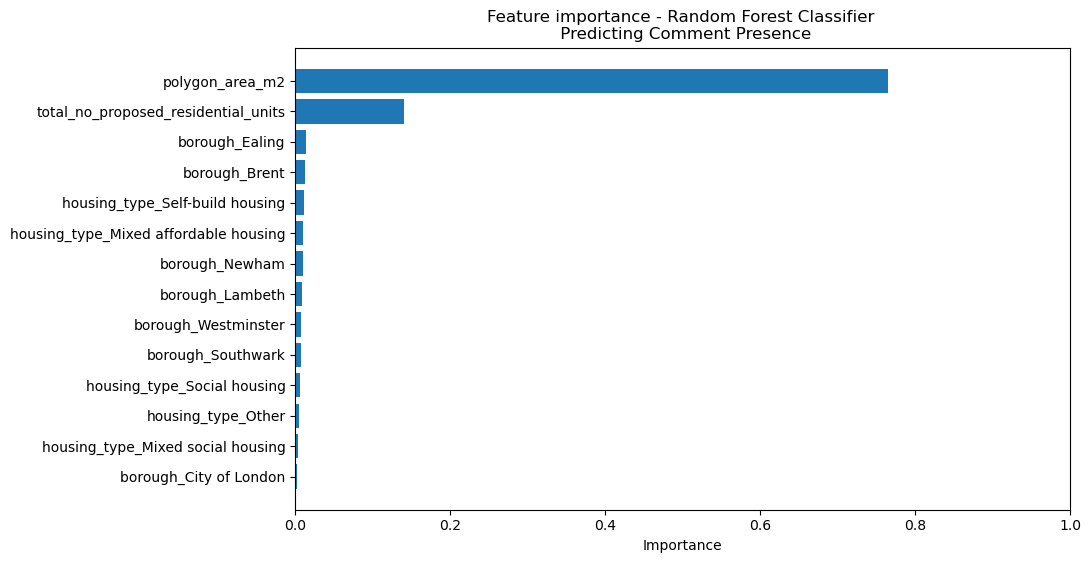

In [28]:
importances = rf.feature_importances_

# create a dataframe for feature importances
feature_importances = pd.DataFrame({'feature': X.columns, 'importance': importances})
# sort the dataframe by importance
feature_importances = feature_importances.sort_values(by='importance', ascending=False)

# plot feature importances
plt.figure(figsize=(10,6))
plt.barh(feature_importances['feature'], feature_importances['importance'])
plt.xlabel('Importance')
plt.xlim(0, 1)
plt.title('Feature importance - Random Forest Classifier \n Predicting Comment Presence')
plt.gca().invert_yaxis()
plt.show()

Predict whether an application will be permitted based on other features using random forest classifier

In [29]:
# define features 
features = ['total_no_proposed_residential_units', 'borough', 'polygon_area_m2', 'housing_type', 'comment_count']
X = df[features]
# define target variable 
y = np.where(df['outcome'] == 'Permitted', 1, 0)
# one-hot encode categorical variables
X = pd.get_dummies(X, columns=['housing_type', 'borough'], drop_first=True)
# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train random forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
# make predictions
y_pred = rf.predict(X_test)

# evaluate model
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n Classification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[   1   12]
 [   2 1001]]

 Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.08      0.12        13
           1       0.99      1.00      0.99      1003

    accuracy                           0.99      1016
   macro avg       0.66      0.54      0.56      1016
weighted avg       0.98      0.99      0.98      1016



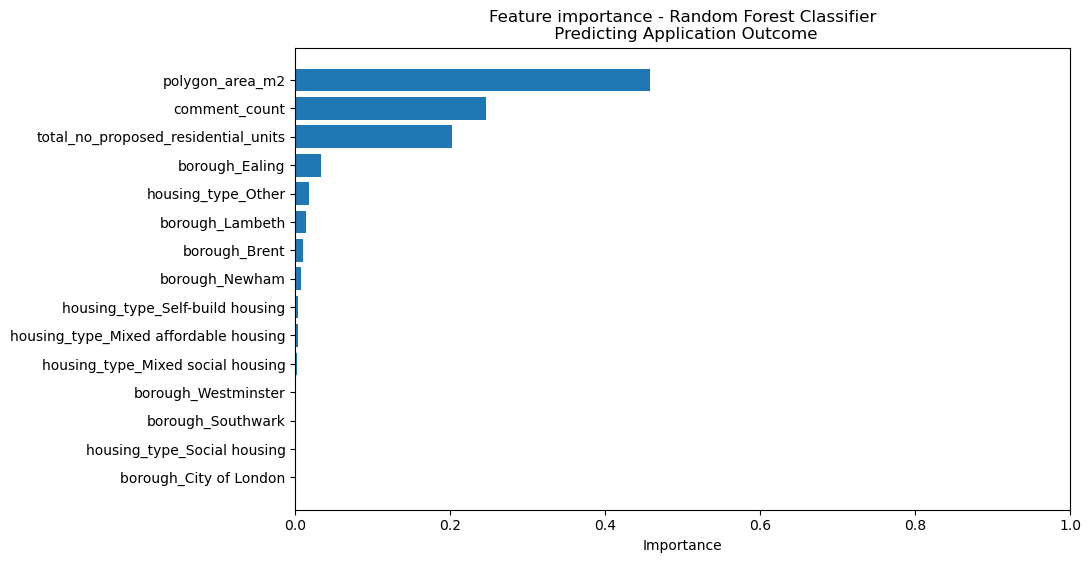

In [30]:
importances = rf.feature_importances_

# create a dataframe for feature importances
feature_importances = pd.DataFrame({'feature': X.columns, 'importance': importances})
# sort the dataframe by importance
feature_importances = feature_importances.sort_values(by='importance', ascending=False)

# plot feature importances
plt.figure(figsize=(10,6))
plt.barh(feature_importances['feature'], feature_importances['importance'])
plt.xlabel('Importance')
plt.xlim(0, 1)
plt.title('Feature importance - Random Forest Classifier\n Predicting Application Outcome')
plt.gca().invert_yaxis()
plt.show()

## Regression model 

In [31]:
print("length of df:", len(df))
# drop rows with na values in relevant columns - as can't be inputs to the regression model
df_nona = df.dropna(subset=['comment_truth', 'borough', 'housing_type', 'total_no_proposed_residential_units', 'polygon_area_m2'])
print("length of df_nona:", len(df_nona))

length of df: 5077
length of df_nona: 4480


In [32]:
# feature set
features = [
    'total_no_proposed_residential_units',
    'polygon_area_m2',
    'housing_type',
    'borough'
]

# dummy encode categorical variables
df_encoded = pd.get_dummies(
    df_nona[features],
    columns=['housing_type', 'borough'],
    drop_first=True
)

# convert ALL boolean dummy columns to integers (required for VIF)
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

In [33]:
# check for multicollinearity using correlation matrix
corr_matrix = df_encoded.corr()

print("Correlation matrix:")
print(corr_matrix)

Correlation matrix:
                                       total_no_proposed_residential_units  \
total_no_proposed_residential_units                               1.000000   
polygon_area_m2                                                   0.282455   
housing_type_Mixed affordable housing                             0.188110   
housing_type_Mixed social housing                                 0.319810   
housing_type_Other                                                0.004703   
housing_type_Self-build housing                                  -0.033116   
housing_type_Social housing                                      -0.003846   
borough_Brent                                                    -0.011348   
borough_City of London                                            0.125568   
borough_Ealing                                                    0.002675   
borough_Lambeth                                                  -0.030108   
borough_Newham                              

In [34]:
# compute variance inflation factor (VIF) for each feature 
X = sm.add_constant(df_encoded)

vif_df = pd.DataFrame({
    "feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

print(vif_df)

                                  feature       VIF
0                                   const  3.778039
1     total_no_proposed_residential_units  1.267313
2                         polygon_area_m2  1.109592
3   housing_type_Mixed affordable housing  1.063314
4       housing_type_Mixed social housing  1.140086
5                      housing_type_Other  1.039557
6         housing_type_Self-build housing  1.011914
7             housing_type_Social housing  1.012216
8                           borough_Brent  1.376708
9                  borough_City of London  1.033809
10                         borough_Ealing  1.319230
11                        borough_Lambeth  1.260483
12                         borough_Newham  1.214096
13                      borough_Southwark  1.174715
14                    borough_Westminster  1.243579


In [35]:
# Regression model using features to predict number of comments
features = ['total_no_proposed_residential_units', 'borough', 'polygon_area_m2', 'housing_type']

X = df_nona[features]
y = df_nona['comment_count']

# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# define the model and train
model1 = smf.ols('comment_count ~ C(borough) + C(housing_type) + total_no_proposed_residential_units + polygon_area_m2', data=df_nona).fit()

# make predictions -  note I haven't added the constant term to X_test
y_pred = model1.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Out of sample R-squared (with intercept): {r2}")

Mean Squared Error: 228.0902396434905
Out of sample R-squared (with intercept): -0.4944979717540243


In [36]:
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          comment_count   R-squared:                       0.088
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     30.75
Date:                Fri, 21 Nov 2025   Prob (F-statistic):           4.67e-79
Time:                        16:01:53   Log-Likelihood:                -21358.
No. Observations:                4480   AIC:                         4.275e+04
Df Residuals:                    4465   BIC:                         4.284e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
===============================================================================================================
                                                  coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
Intercept                                       5.6773      0.828      6.858      0.000       4.054       7.300
C(borough)[T.Brent]                            -4.9114      1.261     -3.894      0.000      -7.384      -2.439
C(borough)[T.City of London]                  -17.9821      6.664     -2.698      0.007     -31.047      -4.917
C(borough)[T.Ealing]                            4.3607      1.354      3.220      0.001       1.705       7.016
C(borough)[T.Lambeth]                          -3.0824      1.572     -1.960      0.050      -6.165       0.000
C(borough)[T.Newham]                           -7.6828      1.648     -4.663      0.000     -10.913      -4.453
C(borough)[T.Southwark]                        -1.8644      1.850     -1.008      0.314      -5.491       1.762
C(borough)[T.Westminster]                      -4.5813      1.527     -3.000      0.003      -7.576      -1.587
C(housing_type)[T.Mixed affordable housing]     8.4011      2.117      3.969      0.000       4.251      12.551
C(housing_type)[T.Mixed social housing]        10.6137      4.511      2.353      0.019       1.769      19.458
C(housing_type)[T.Other]                       -2.5445      3.341     -0.762      0.446      -9.095       4.006
C(housing_type)[T.Self-build housing]          -0.0223      1.888     -0.012      0.991      -3.724       3.679
C(housing_type)[T.Social housing]               4.4630      3.297      1.354      0.176      -2.001      10.927
total_no_proposed_residential_units             0.0860      0.006     13.660      0.000       0.074       0.098
polygon_area_m2                                 0.0003   8.15e-05      4.040      0.000       0.000       0.000
==============================================================================
Omnibus:                     8594.100   Durbin-Watson:                   1.990
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         17443166.958
Skew:                          14.810   Prob(JB):                         0.00
Kurtosis:                     307.250   Cond. No.                     8.71e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.71e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

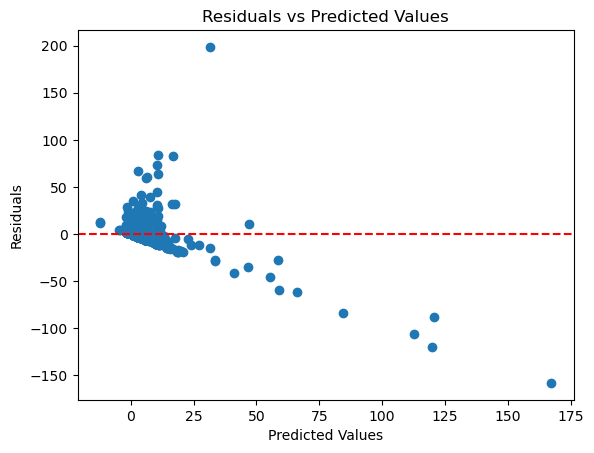

In [37]:
# plot model residuals
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()

In [38]:
# log version of the model to handle skewness in comment_count - performs slightly worse

df_nona["log_comments"] = np.log1p(df_nona["comment_count"])  # handles zeros safely

model2 = smf.ols(
    'log_comments ~ C(borough) + C(housing_type) + total_no_proposed_residential_units + polygon_area_m2',
    data=df_nona
).fit()

# make predictions -  note I haven't added the constant term to X_test
y_pred = model2.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Out of sample R-squared (with intercept): {r2}")
print(model2.summary())


Mean Squared Error: 160.7479952851759
Out of sample R-squared (with intercept): -0.05325661147411176
                            OLS Regression Results                            
Dep. Variable:           log_comments   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                     26.97
Date:                Fri, 21 Nov 2025   Prob (F-statistic):           7.71e-69
Time:                        16:01:53   Log-Likelihood:                -6564.5
No. Observations:                4480   AIC:                         1.316e+04
Df Residuals:                    4465   BIC:                         1.326e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.97

/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_65647/2107337659.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nona["log_comments"] = np.log1p(df_nona["comment_count"])  # handles zeros safely


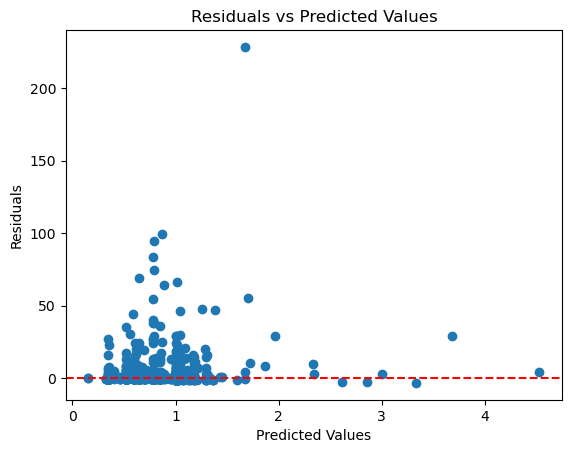

In [39]:
# plot model residuals
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()

In [40]:
# Generalised linear model 

import statsmodels.api as sm

model_nb = smf.glm(
    'comment_count ~ C(borough) + C(housing_type) + total_no_proposed_residential_units + polygon_area_m2',
    data=df_nona,
    family=sm.families.NegativeBinomial()
).fit()

# make predictions 
y_pred = model_nb.predict(X_test)

model_nb.summary()

/opt/miniconda3/envs/nlp_env_analysis/lib/python3.10/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:          comment_count   No. Observations:                 4480
Model:                            GLM   Df Residuals:                     4465
Model Family:        NegativeBinomial   Df Model:                           14
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10979.
Date:                Fri, 21 Nov 2025   Deviance:                       11437.
Time:                        16:01:53   Pearson chi2:                 3.18e+04
No. Iterations:                   100   Pseudo R-squ. (CS):             0.4929
Covariance Type:            nonrobust                                         
===============================================================================================================
                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
Intercept                                       1.4977      0.032     46.929      0.000       1.435       1.560
C(borough)[T.Brent]                            -0.9593      0.052    -18.367      0.000      -1.062      -0.857
C(borough)[T.City of London]                   -1.7479      0.323     -5.414      0.000      -2.381      -1.115
C(borough)[T.Ealing]                            0.5378      0.051     10.567      0.000       0.438       0.638
C(borough)[T.Lambeth]                          -0.3329      0.062     -5.361      0.000      -0.455      -0.211
C(borough)[T.Newham]                           -1.4435      0.074    -19.418      0.000      -1.589      -1.298
C(borough)[T.Southwark]                        -0.0089      0.071     -0.125      0.900      -0.148       0.130
C(borough)[T.Westminster]                      -0.8508      0.064    -13.398      0.000      -0.975      -0.726
C(housing_type)[T.Mixed affordable housing]     0.5508      0.081      6.822      0.000       0.393       0.709
C(housing_type)[T.Mixed social housing]        -0.0960      0.169     -0.568      0.570      -0.427       0.235
C(housing_type)[T.Other]                       -0.6193      0.151     -4.092      0.000      -0.916      -0.323
C(housing_type)[T.Self-build housing]           0.1264      0.075      1.680      0.093      -0.021       0.274
C(housing_type)[T.Social housing]               0.5059      0.127      3.984      0.000       0.257       0.755
total_no_proposed_residential_units             0.0054      0.000     23.926      0.000       0.005       0.006
polygon_area_m2                              9.997e-05   2.88e-06     34.697      0.000    9.43e-05       0.000
===============================================================================================================
"""

In [41]:
# MAE

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

# RMSLE (good for count models)
from sklearn.metrics import mean_squared_log_error
rmsle = mean_squared_log_error(y_test, y_pred) ** 0.5
print("RMSLE:", rmsle)

# Deviance
from sklearn.metrics import mean_poisson_deviance
deviance = mean_poisson_deviance(y_test, y_pred)
print("Mean Poisson deviance:", deviance)

MAE: 2858.861887518099
RMSLE: 1.472571293533146
Mean Poisson deviance: 5716.9238064399115


### Cluster analysis 

In [94]:
# feature set
features = [
    'total_no_proposed_residential_units',
    'polygon_area_m2',
    'housing_type',
    'borough', 
    'comment_count'
]

# dummy encode categorical variables
df_cluster = pd.get_dummies(
    df_nona[features],
    columns=['housing_type', 'borough'],
    drop_first=True
)

# convert ALL boolean dummy columns to integers (required for VIF)
bool_cols = df_cluster.select_dtypes(include=['bool']).columns
df_cluster[bool_cols] = df_cluster[bool_cols].astype(int)

In [95]:
# exlcude item at index 340 - as I think it's an outlier
df_cluster = df_cluster.drop(index=340)

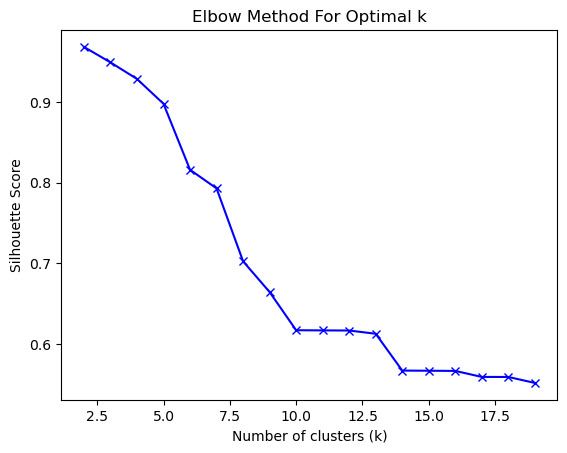

In [96]:
# Determine optimal number of clusters using silhouette score
K = range(2, 20)
fits = []
score = []


for k in K:
    # train the model for current value of k on training data
    model = KMeans(n_clusters = k, random_state = 0, n_init='auto').fit(df_cluster)
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    score.append(silhouette_score(X, model.labels_, metric='euclidean'))

# elbow plot of silhouette scores
plt.plot(K, score, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Elbow Method For Optimal k')
plt.show()

In [97]:
# save results for k=5
elbow_k = 5
kmeans = KMeans(n_clusters=elbow_k, random_state=42)
kmeans.fit(df_cluster)
df_cluster['cluster'] = kmeans.labels_

In [98]:
# generate PCAs 

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_cluster.drop(columns=['cluster']))
df_cluster['pca1'] = pca_result[:, 0]
df_cluster['pca2'] = pca_result[:, 1]

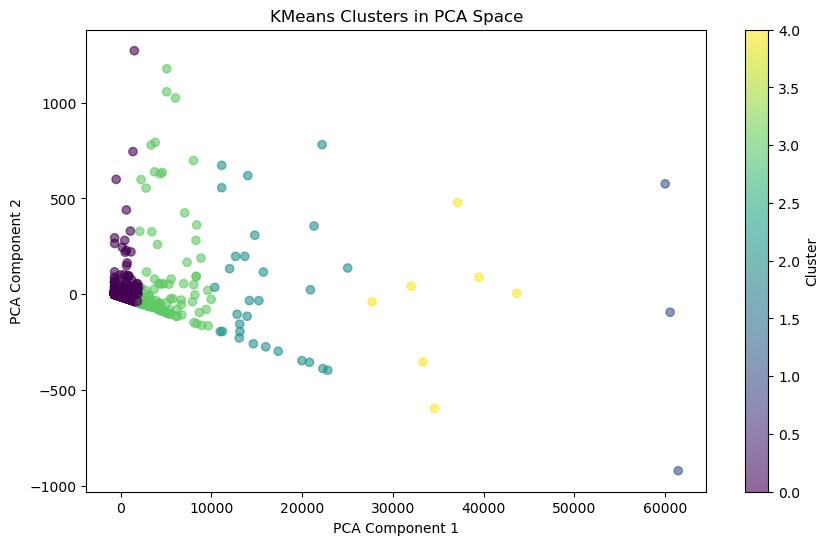

In [99]:
plt.figure(figsize=(10,6))
plt.scatter(df_cluster['pca1'], df_cluster['pca2'], c=df_cluster['cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('KMeans Clusters in PCA Space')
plt.colorbar(label='Cluster')
plt.show()

In [101]:
# print features of PCA components
print("PCA Component 1 features:")
for i, component in enumerate(pca.components_[0]):
    print(f"{df_cluster.columns[i]}: {component}")

print("PCA Component 2 features:")
for i, component in enumerate(pca.components_[1]):
    print(f"{df_cluster.columns[i]}: {component}")

PCA Component 1 features:
total_no_proposed_residential_units: 0.01679850060677963
polygon_area_m2: 0.9998541082167651
comment_count: 0.0030939072089865814
housing_type_Mixed affordable housing: 1.5665995238623494e-05
housing_type_Mixed social housing: 1.0457745063519954e-05
housing_type_Other: 9.45979342661831e-07
housing_type_Self-build housing: -1.809328024723388e-06
housing_type_Social housing: 2.1166620835127736e-06
borough_Brent: -1.448416735283727e-06
borough_City of London: -5.7482178592648395e-08
borough_Ealing: -1.2407645288823546e-06
borough_Lambeth: -4.531134955185572e-07
borough_Newham: 4.251170825895332e-06
borough_Southwark: 6.634574608148924e-07
borough_Westminster: -3.4361291607668747e-06
PCA Component 2 features:
total_no_proposed_residential_units: 0.9975448819202336
polygon_area_m2: -0.01696994423580256
comment_count: 0.06794051178579066
housing_type_Mixed affordable housing: 0.0002947856939769162
housing_type_Mixed social housing: 0.00031872293613536624
housing_typ

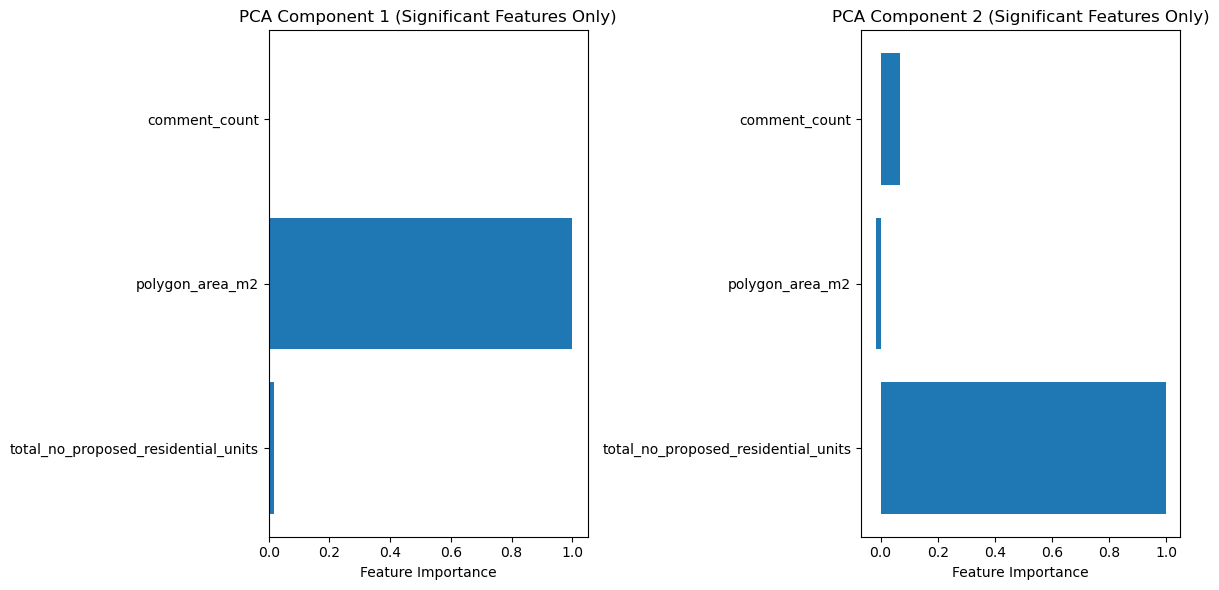

In [104]:
# PCA components
components = pca.components_   # first two components
feature_names = df_cluster.drop(columns=['cluster', 'pca1', 'pca2']).columns

# choose a loading threshold for "significance"
threshold = 0.05

# boolean mask: feature is significant in PC1 OR PC2
sig_mask = (np.abs(components[0]) >= threshold) | (np.abs(components[1]) >= threshold)

# filter features + component loadings
features_sig = feature_names[sig_mask]
components_sig = components[:, sig_mask]

# plot
plt.figure(figsize=(12, 6))
for i in range(2):
    plt.subplot(1, 2, i + 1)
    plt.barh(features_sig, components_sig[i])
    plt.xlabel('Feature Importance')
    plt.title(f'PCA Component {i+1} (Significant Features Only)')
plt.tight_layout()
plt.show()


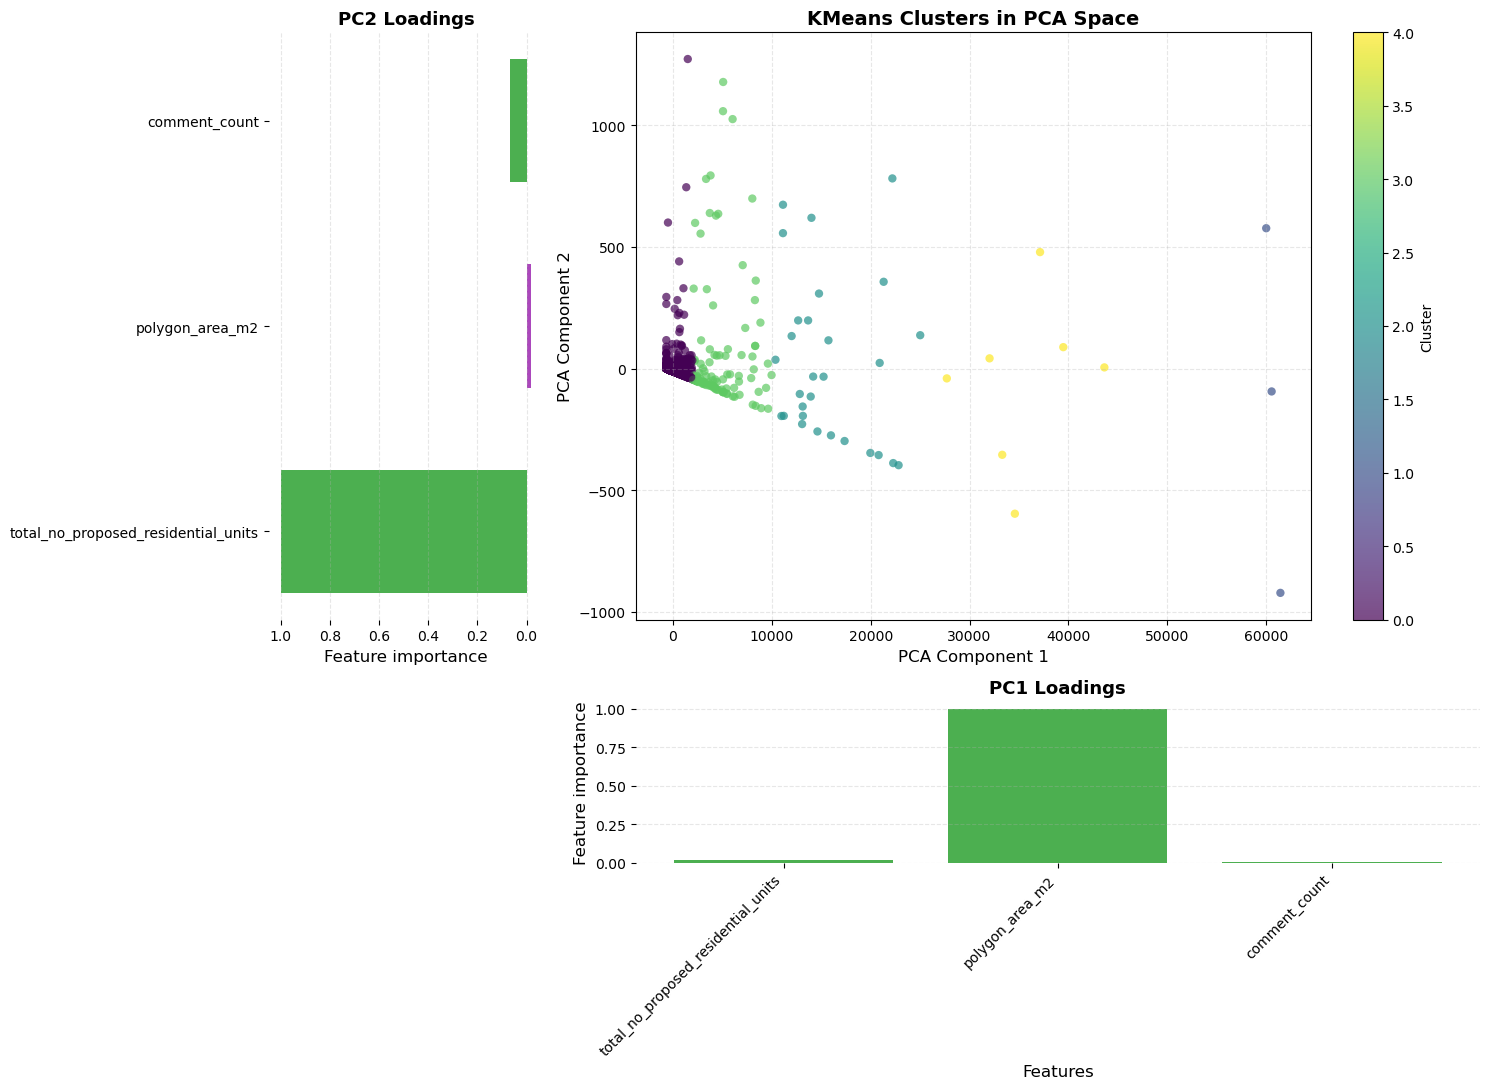

In [110]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# PCA loadings
components = pca.components_
feature_names = df_cluster.drop(columns=['cluster', 'pca1', 'pca2']).columns

# threshold for significant features
threshold = 0.05
sig_mask = (np.abs(components[0]) >= threshold) | (np.abs(components[1]) >= threshold)
features_sig = feature_names[sig_mask]
pc1 = components[0, sig_mask]
pc2 = components[1, sig_mask]

# Colors: positive = green, negative = purple
def signed_colors(values):
    return ["#4caf50" if v > 0 else "#ab47bc" for v in values]

# Layout
fig = plt.figure(figsize=(15, 11))
gs = GridSpec(2, 2, width_ratios=[1.3, 4], height_ratios=[4, 1.1], figure=fig)

ax_left   = fig.add_subplot(gs[0, 0])   # PC2 barh
ax_main   = fig.add_subplot(gs[0, 1])   # PCA scatter
ax_bottom = fig.add_subplot(gs[1, 1])   # PC1 vertical bars

# -------------------------------------------------------------
# Main PCA scatter (clean style)
# -------------------------------------------------------------
sc = ax_main.scatter(
    df_cluster['pca1'],
    df_cluster['pca2'],
    c=df_cluster['cluster'],
    cmap='viridis',
    alpha=0.7,
    edgecolor="none"
)

ax_main.set_title("KMeans Clusters in PCA Space", fontsize=14, weight="bold")
ax_main.set_xlabel("PCA Component 1", fontsize=12)
ax_main.set_ylabel("PCA Component 2", fontsize=12)
fig.colorbar(sc, ax=ax_main, label="Cluster")

ax_main.grid(alpha=0.3, linestyle="--")

# -------------------------------------------------------------
# PC2 horizontal barh (left)
# -------------------------------------------------------------
colors_pc2 = signed_colors(pc2)
ax_left.barh(features_sig, pc2, color=colors_pc2, height=0.6)

ax_left.set_xlabel("Feature importance", fontsize=12)
ax_left.set_title("PC2 Loadings", fontsize=13, weight="bold")

ax_left.grid(axis="x", alpha=0.3, linestyle="--")
ax_left.invert_xaxis()      # bars point inward
ax_left.tick_params(axis='y', labelsize=10)

# Cleaner look
for spine in ax_left.spines.values():
    spine.set_visible(False)

# -------------------------------------------------------------
# PC1 vertical bars (bottom)
# -------------------------------------------------------------
xpos = np.arange(len(features_sig))
colors_pc1 = signed_colors(pc1)
ax_bottom.bar(xpos, pc1, color=colors_pc1)

ax_bottom.set_xticks(xpos)
ax_bottom.set_xticklabels(features_sig, rotation=45, ha="right", fontsize=10)

ax_bottom.set_ylabel("Feature importance", fontsize=12)
ax_bottom.set_xlabel("Features", fontsize=12)
ax_bottom.set_title("PC1 Loadings", fontsize=13, weight="bold")

ax_bottom.grid(axis="y", alpha=0.3, linestyle="--")

for spine in ax_bottom.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()


### XGBoost model 

In [121]:
# define features 
features = ['total_no_proposed_residential_units', 'borough', 'polygon_area_m2', 'housing_type']
X = df[features]
# define target variable 
y = df['comment_truth']

# Extract text features
cats = X.select_dtypes(exclude=np.number).columns.tolist()

# Convert to Pandas category
for col in cats:
   X[col] = X[col].astype('category')

/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_65647/956825384.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype('category')
/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_65647/956825384.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype('category')


In [122]:
X.dtypes

total_no_proposed_residential_units       int64
borough                                category
polygon_area_m2                         float64
housing_type                           category
dtype: object

In [123]:
# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create regression matrices - these are xgb.DMatrix objects
dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True)
dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True)

In [124]:
# Define hyperparameters
params = {"objective": "reg:squarederror", "tree_method": "hist"}

evals = [(dtrain_reg, "train"), (dtest_reg, "validation")]

n = 100
model = xgb.train(
   params=params,
   dtrain=dtrain_reg,
   num_boost_round=n,
   evals=evals
)

[0]	train-rmse:0.47897	validation-rmse:0.48490
[1]	train-rmse:0.46582	validation-rmse:0.47921
[2]	train-rmse:0.45686	validation-rmse:0.47630
[3]	train-rmse:0.45138	validation-rmse:0.47546
[4]	train-rmse:0.44708	validation-rmse:0.47402
[5]	train-rmse:0.44288	validation-rmse:0.47512
[6]	train-rmse:0.43961	validation-rmse:0.47593
[7]	train-rmse:0.43773	validation-rmse:0.47651
[8]	train-rmse:0.43490	validation-rmse:0.47672
[9]	train-rmse:0.43343	validation-rmse:0.47780
[10]	train-rmse:0.43182	validation-rmse:0.47718
[11]	train-rmse:0.43084	validation-rmse:0.47720
[12]	train-rmse:0.42989	validation-rmse:0.47719
[13]	train-rmse:0.42758	validation-rmse:0.47758
[14]	train-rmse:0.42711	validation-rmse:0.47775
[15]	train-rmse:0.42688	validation-rmse:0.47773
[16]	train-rmse:0.42451	validation-rmse:0.47734
[17]	train-rmse:0.42169	validation-rmse:0.47686
[18]	train-rmse:0.42042	validation-rmse:0.47627
[19]	train-rmse:0.41893	validation-rmse:0.47663
[20]	train-rmse:0.41680	validation-rmse:0.47694
[2

In [125]:
results = xgb.cv(
   params, dtrain_reg,
   num_boost_round=n,
   nfold=5,
   early_stopping_rounds=20
)

results.head()

,train-rmse-mean,train-rmse-std,test-rmse-mean,test-rmse-std
0,0.477396,0.001362,0.486256,0.002496
1,0.463473,0.001410,0.480206,0.004959
2,0.454079,0.001876,0.477293,0.005908
3,0.447630,0.001965,0.476817,0.006900


In [126]:
best_rmse = results['test-rmse-mean'].min()

best_rmse

0.47681669575886676

In [127]:
# fetaure importance for xgboost model
importance = model.get_score(importance_type='weight')
importance_df = pd.DataFrame({'feature': list(importance.keys()), 'importance': list(importance.values())})
importance_df = importance_df.sort_values(by='importance', ascending=False)

importance_df.head(10)

,feature,importance
2,polygon_area_m2,1797.0
0,total_no_proposed_residential_units,1237.0
1,borough,899.0
3,housing_type,323.0


In [129]:
# plot feature importance using shap
import shap

ModuleNotFoundError: No module named 'shap'

## Simple neural network model 

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

# Define features and target (already one-hot encoded)
features = ['total_no_proposed_residential_units', 'polygon_area_m2'] + \
           [col for col in X.columns if col.startswith('borough_') or col.startswith('housing_type_')]

X_nn = X[features].values
y_nn = y.values

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X_nn, y_nn, test_size=0.2, random_state=42)

# Define the model
model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Make predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Evaluate
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


ModuleNotFoundError: No module named 'tensorflow'